# Data Preparation Pipeline

## Purpose

This notebook demonstrates the streamlined data preparation pipeline for the reinforcement learning portfolio rebalancing system using the leak-proof `complete_data_pipeline()` function.

## Key Features

1. **Leak-Proof Design**: Split-first approach ensures no data leakage between train/test
2. **Enhanced Macro Indicators**: 15+ FRED economic indicators
3. **Comprehensive Features**: 160+ technical, fundamental, and macro features
4. **Automated Processing**: Single function call handles all preprocessing steps

## Pipeline Steps (Automated)

The `complete_data_pipeline()` function handles:
1. Data acquisition from Yahoo Finance
2. Feature engineering (momentum, volatility, volume, risk-adjusted, etc.)
3. Temporal train/test split (80/20)
4. Outlier removal and normalization
5. Correlation filtering
6. Data quality validation

## Outputs

- `data/processed/train.parquet`: Training set (normalized)
- `data/processed/test.parquet`: Test set (normalized with train statistics)
- `data/processed/scaler.pkl`: Fitted scaler for inference
- `data/processed/metadata.json`: Feature list and metadata

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from utile import (
    complete_data_pipeline,
    verify_data_quality,
    categorize_features,
    print_feature_summary,
    verify_regime_features,
    save_processed_data
)

from viz import (
    plot_price_data,
    plot_regime_features,
    plot_feature_distributions,
    analyze_feature_importance
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Define assets, date range, and pipeline parameters.

In [2]:
# Configuration
TICKERS = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
START_DATE = '2020-01-01'
END_DATE = '2025-11-01'
INTERVAL = '1wk'

# Directories
DATA_DIR = project_root / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
RESULTS_DIR = project_root / 'results'

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Tickers: {', '.join(TICKERS)}")
print(f"  Date range: {START_DATE} to {END_DATE}")
print(f"  Interval: {INTERVAL}")
print(f"  Output directory: {PROCESSED_DATA_DIR}")

Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Date range: 2020-01-01 to 2025-11-01
  Interval: 1wk
  Output directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed


## Run Complete Data Pipeline

Execute the leak-proof data pipeline with all preprocessing steps.

In [3]:
print("=" * 80)
print("RUNNING LEAK-PROOF DATA PIPELINE")
print("=" * 80)

result = complete_data_pipeline(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    include_macro=True,
    include_sentiment=False,  # Set to True if you have NewsAPI key
    train_ratio=0.8,
    clip_percentiles=(0.01, 0.99),
    corr_threshold=0.98
)

train_df = result['train']
test_df = result['test']
scaler = result['scaler']
metadata = result['metadata']

print("\n✓ Pipeline completed successfully!")
print(f"  Train samples: {len(train_df)}")
print(f"  Test samples:  {len(test_df)}")
print(f"  Features:      {len(metadata['feature_cols'])}")

RUNNING LEAK-PROOF DATA PIPELINE
LEAK-PROOF DATA PREPARATION PIPELINE

[1/7] Fetching price data...
  ✓ Fetched 2135 rows for 7 tickers

[2/7] Splitting data (chronological)...
  ✓ Train: 1708 rows (2020-01-01 00:00:00 to 2024-08-28 00:00:00)
  ✓ Test:  427 rows (2024-09-04 00:00:00 to 2025-10-29 00:00:00)

[3/7] Fetching benchmark returns (QQQ)...
  ✓ Fetched benchmark returns

[4/7] Fetching macro indicators from FRED...
  ✓ Fetched 14 macro indicators

[5/7] Skipping sentiment data (include_sentiment=False)

[6/7] Engineering features...
  → Training set...
  → Test set...
  ✓ Engineered 179 columns

[7/7] Preprocessing (outliers, correlations, normalization)...


/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/utile.py:1284: UserWarning: Removed 1 constant features: ['cpi_yoy']
  warnings.warn(f"Removed {len(constant_features)} constant features: {constant_features}", UserWarning)


  ✓ Original features: 172
  ✓ Removed features: 23
  ✓ Final features: 149

✓ PIPELINE COMPLETE
Train samples: 1708
Test samples:  427
Features:      149


✓ Pipeline completed successfully!
  Train samples: 1708
  Test samples:  427
  Features:      149


/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/utile.py:1352: UserWarning: Removed 22 highly correlated features (threshold=0.98): ['bb_position_20w', 'pain_index_26w', 'volume_sma_ratio', 'relative_momentum', 'avg_drawdown_52w', 'price_to_ema_8w', 'ulcer_index_13w', 'price_position_13w', 'pain_index_13w', 'return_26w']...
  warnings.warn(


## Verification Tests

Verify data quality and check for common issues.

In [ ]:
# Get feature columns
non_feature_cols = ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

# Verify data quality
verify_data_quality(train_df, test_df, feature_cols)

VERIFICATION TESTS

[Test 1] Checking for data leakage (temporal overlap)...
  ✓ PASS: No overlap
    Train ends:  2024-08-28
    Test starts: 2024-09-04
    Gap:         7 days

[Test 2] Checking feature consistency...
  ✓ PASS: Train and test have same 156 columns

[Test 3] Checking normalization...
  Train mean: 0.0000 (target: ~0.00)
  Train std:  1.0003 (target: ~1.00)
  ✓ PASS: Training set properly normalized

[Test 4] Checking macro indicators...
  Found 12 macro indicator columns:
    - baa_aaa_spread
    - cpi
    - dxy
    - fed_funds_rate
    - high_yield_spread
    - ism_manufacturing
    - oil_wti
    - treasury_10y
    - treasury_2y
    - unemployment_rate
    ... and 2 more
  ✓ PASS: Comprehensive macro coverage

[Test 5] Checking data quality...
  Train NaN: 0.00%
  Test NaN:  0.00%
  ✓ PASS: Low missing data


## Data Visualizations

Visualize price data and feature distributions.

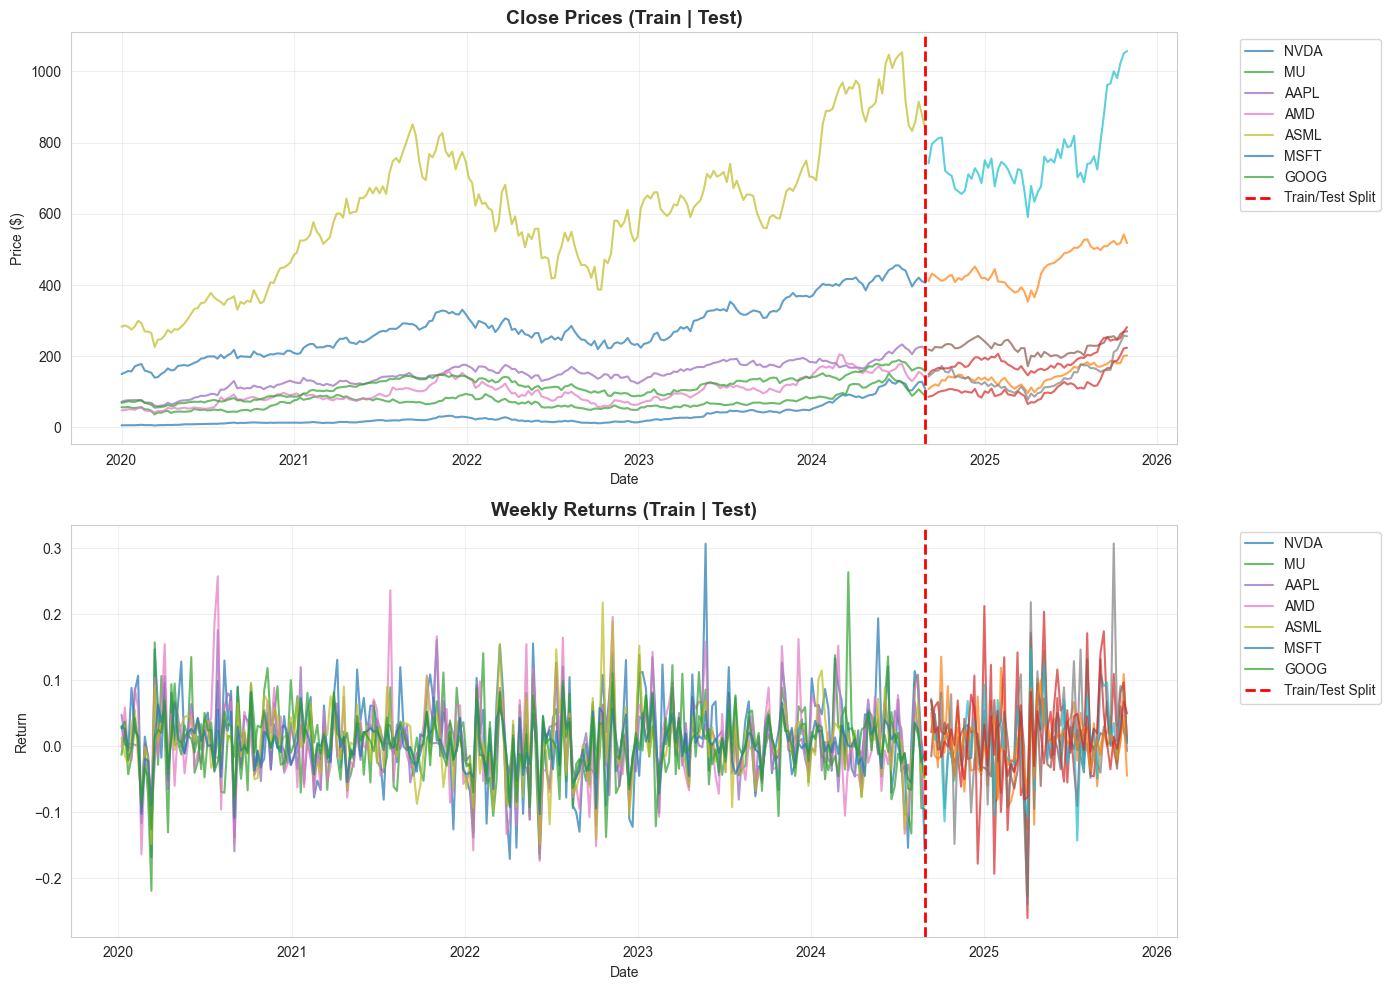

In [ ]:
# Visualize price data over time
plot_price_data(train_df, test_df, TICKERS, RESULTS_DIR)

## Feature Summary

Display feature categories and statistics.

In [ ]:
# Get macro columns for categorization
macro_keywords = ['treasury', 'fed_funds', 'vix', 'cpi', 'unemployment',
                  'ism', 'yield_curve', 'dxy', 'oil', 'spread', 'pce', 'baa']
macro_cols = [c for c in train_df.columns if any(kw in c.lower() for kw in macro_keywords)]

# Categorize features
feature_categories = categorize_features(feature_cols, macro_cols)

# Display summary
print_feature_summary(feature_cols, feature_categories)

FEATURE SUMMARY

Total features: 149

Momentum            :  31 features
Volume              :  28 features
Volatility          :  24 features
Drawdown            :  22 features
Technical           :  21 features
Risk-Adjusted       :  12 features
Macro               :  12 features
Statistical         :   6 features
Other               :   6 features
Calendar            :   4 features

SAMPLE FEATURES BY CATEGORY

Momentum (showing up to 5):
  - rsi_7d
  - rsi_14d
  - rsi_21d
  - roc_1w
  - roc_4w

Volume (showing up to 5):
  - obv
  - obv_roc_1w
  - obv_roc_4w
  - obv_roc_13w
  - obv_roc_26w

Volatility (showing up to 5):
  - volatility_4w
  - volatility_13w
  - volatility_52w
  - realized_volatility_4w
  - realized_volatility_26w

Drawdown (showing up to 5):
  - current_drawdown
  - drawdown_duration
  - max_drawdown_4w
  - drawdown_volatility_4w
  - recovery_factor_4w

Technical (showing up to 5):
  - price_to_sma_4w
  - price_to_ema_4w
  - price_to_sma_8w
  - price_to_sma_12w
  - p

## Regime and Concentration Features

Verify the newly added regime indicators and market concentration features.


REGIME AND CONCENTRATION FEATURES VERIFICATION

✓ Found 4 regime/concentration features:

  bull_market:
    Train: mean=0.0000, std=1.0003, min=-0.8869, max=1.1275
    Test:  mean=-0.6227, std=0.6808, min=-0.8869, max=1.1275

  bear_market:
    Train: mean=0.0000, std=1.0003, min=-0.5656, max=1.7679
    Test:  mean=-0.4891, std=0.4160, min=-0.5656, max=1.7679

  market_concentration:
    Train: mean=0.0000, std=1.0003, min=-1.4665, max=2.6585
    Test:  mean=-1.4650, std=0.0120, min=-1.4665, max=-1.3720

  returns_52w:
    Train: mean=0.0000, std=1.0003, min=-2.4670, max=2.7209
    Test:  mean=-0.4320, std=0.3697, min=-0.5624, max=1.5406


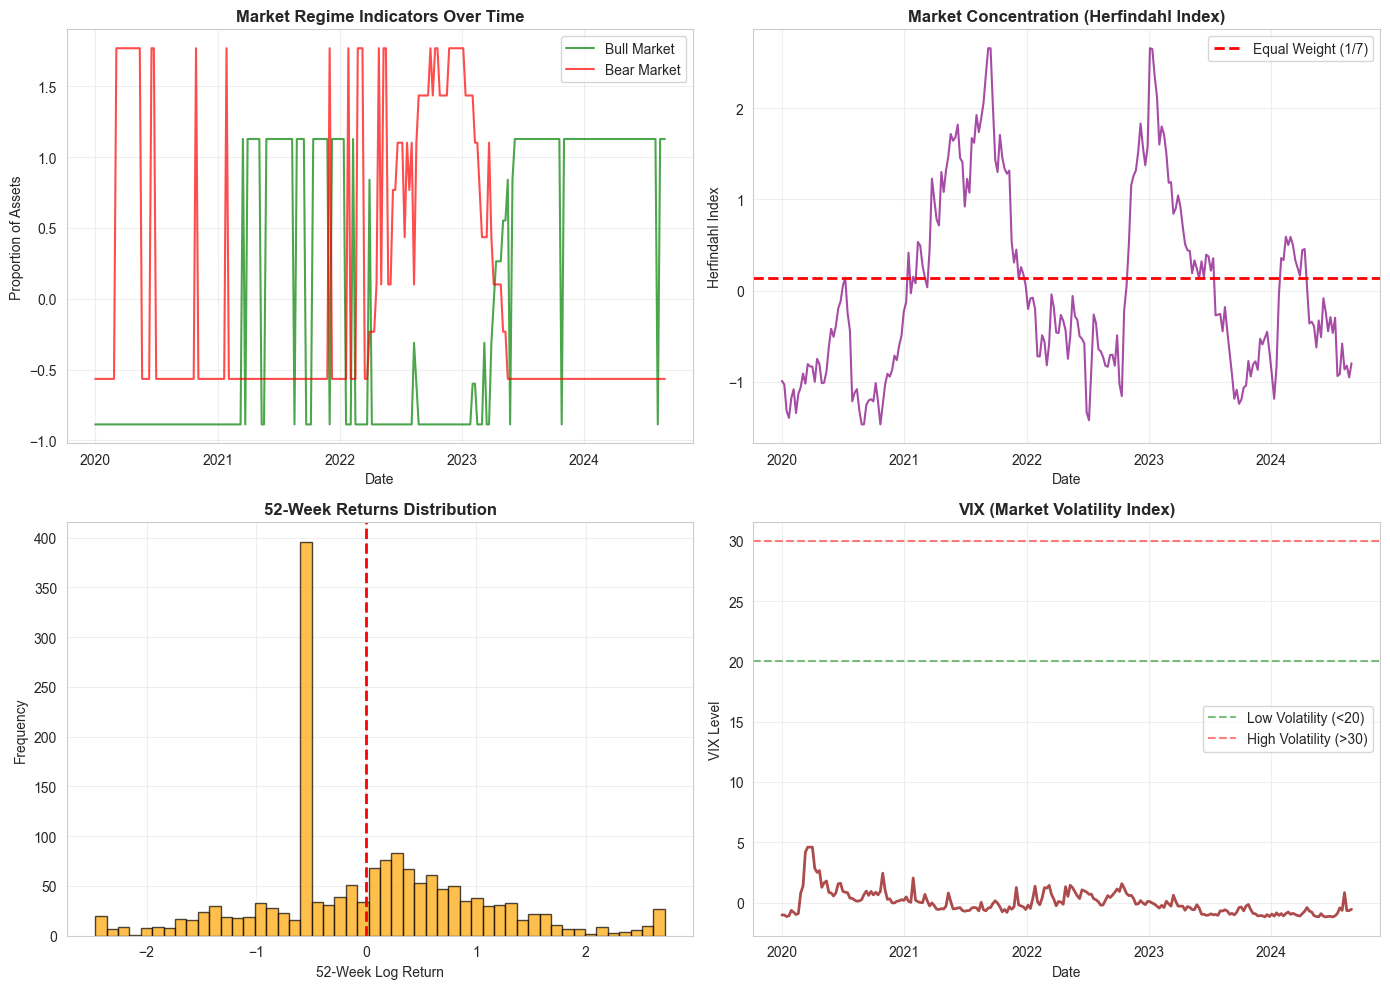


✓ Regime and concentration features successfully added to pipeline


In [ ]:
# Verify and plot regime features
verify_regime_features(train_df, test_df)
plot_regime_features(train_df, test_df, TICKERS, RESULTS_DIR)


## Feature Distributions

Visualize normalized feature distributions to verify proper scaling.

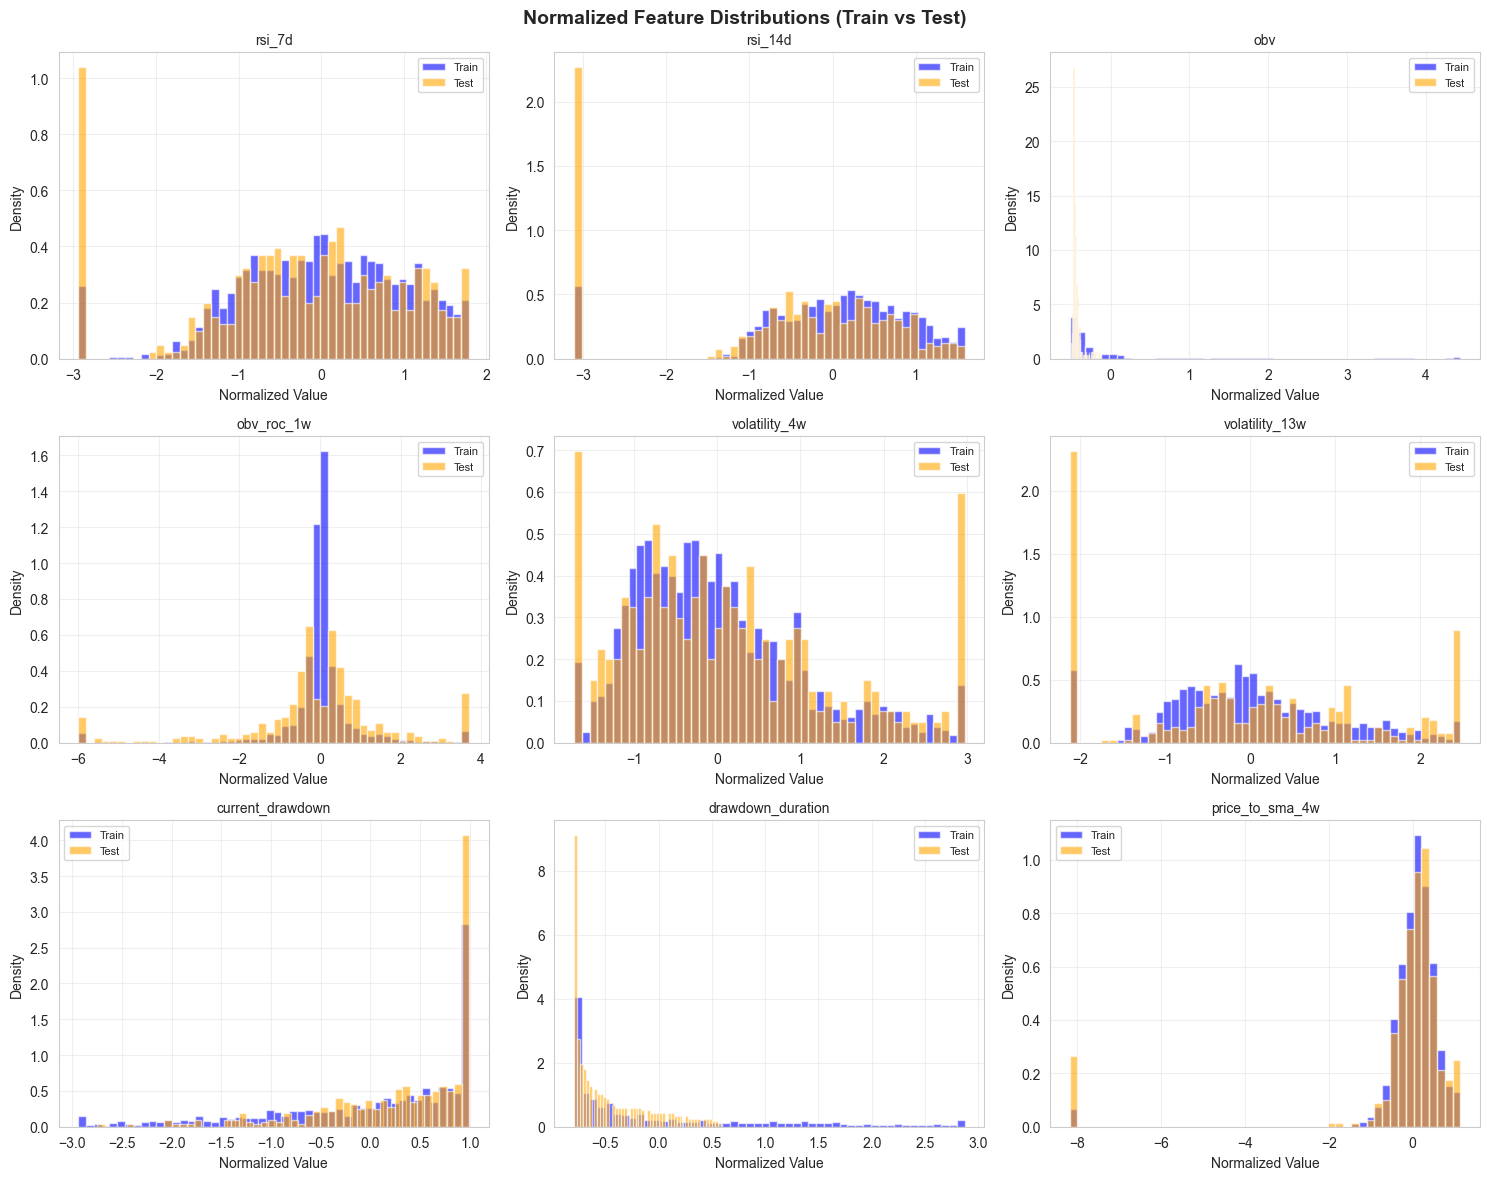

In [ ]:
# Plot feature distributions
plot_feature_distributions(train_df, test_df, feature_categories, RESULTS_DIR)

## Feature Importance Analysis

Identify the most important features using Random Forest to understand which features drive predictions.

In [ ]:
# Analyze feature importance
feature_importance = analyze_feature_importance(
    train_df, 
    feature_cols, 
    RESULTS_DIR,
    n_estimators=100,
    max_depth=10,
    top_n=50
)

Training Random Forest for feature importance...
  Samples: 1701
  Features: 149
✓ Model trained. R² score: 0.5193

TOP 50 MOST IMPORTANT FEATURES

These features have the highest predictive power for future returns:

11. oil_wti                             [MACRO     ] ██████████████████████████████████ 0.068431
149. market_concentration                [TECHNICAL ] ██████████████████████ 0.045924
 7. high_yield_spread                   [MACRO     ] ███████████████████ 0.038591
 6. baa_aaa_spread                      [MACRO     ] █████████████████ 0.034584
13. rsi_7d                              [MOMENTUM  ] █████████████ 0.026843
144. sin_dom                             [TECHNICAL ] ████████████ 0.025443
 8. vix                                 [MACRO     ] ███████████ 0.023379
91. volume_trend_strength               [VOLUME    ] ███████████ 0.022665
 1. treasury_10y                        [MACRO     ] ███████████ 0.022410
 4. yield_curve_10y2y                   [MACRO     ] ████████ 0

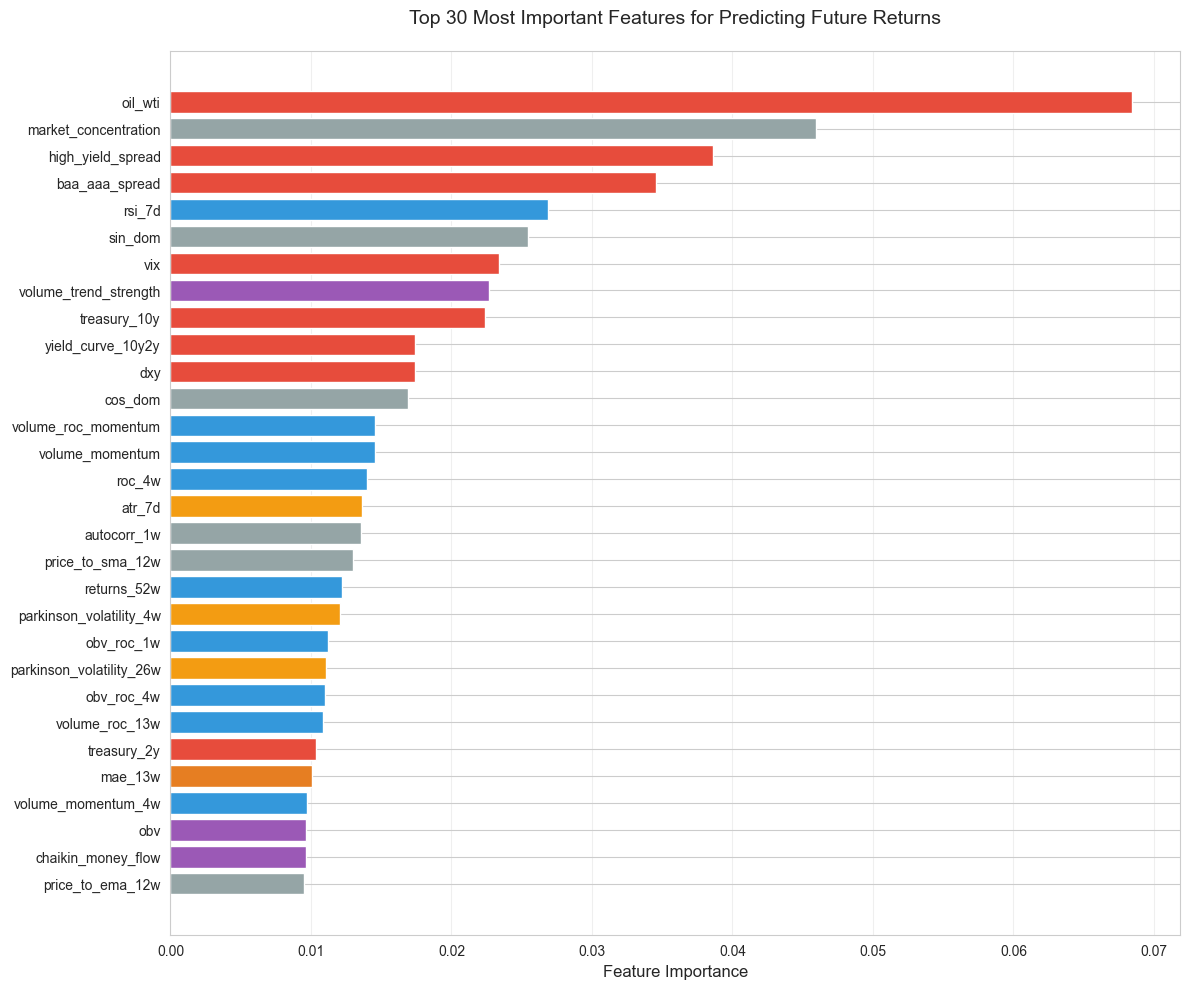


IMPORTANCE BY CATEGORY (Top 50 Features)
Macro Economic      :  8 features, Avg importance: 0.029065
Momentum/Trend      : 13 features, Avg importance: 0.011802
Technical           :  9 features, Avg importance: 0.016596
Volume/Liquidity    :  8 features, Avg importance: 0.009338
Volatility/Risk     :  8 features, Avg importance: 0.009114
Drawdown/Path       :  2 features, Avg importance: 0.008017
Risk-Adjusted       :  2 features, Avg importance: 0.006465


In [ ]:
# Feature importance analysis already includes visualization and category breakdown
# The function returns the feature_importance DataFrame for further analysis if needed

## Save Processed Data

Save the processed datasets, scaler, and metadata for use in RL training.

In [ ]:
# Save processed data
save_processed_data(train_df, test_df, scaler, metadata, PROCESSED_DATA_DIR, RESULTS_DIR)

SAVING RESULTS

✓ Saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed
  - train.parquet (1708 samples)
  - test.parquet (427 samples)
  - scaler.pkl
  - metadata.json (149 features)

PIPELINE COMPLETE

You can now use these files for RL training:
  1. Load data: pd.read_parquet('/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/train.parquet')
  2. Load scaler: pickle.load(open('/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/scaler.pkl', 'rb'))
  3. Load metadata: json.load(open('/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/metadata.json'))

Visualization saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results
  - price_data_over

## Summary

The data preparation pipeline has been successfully completed using the leak-proof `complete_data_pipeline()` function.

### Key Features

- **No Data Leakage**: Split-first approach ensures train/test temporal separation
- **Comprehensive Features**: 130+ features across momentum, volatility, volume, macro, and technical indicators
- **Proper Normalization**: Features standardized using training set statistics only
- **Quality Validation**: Automated tests verify data integrity

### Next Steps

1. **Review metadata**: Check `data/processed/metadata.json` for feature list
2. **Inspect visualizations**: Review plots in `results/` directory
3. **Train RL agent**: Use processed data with your RL environment
4. **Monitor performance**: Compare train vs test metrics to detect overfitting